# Deep Learning: Convolutional Neural Networks - Final Assignment


## Data description

Waste management is a big problem around the world. Most of the wastes end up in landfills. This leads to many issues like  
- Increase in landfills
- Eutrophication
- Consumption of toxic waste by animals
- Leachate
- Increase in toxins
- Land, water and air pollution

I will be using the Waste Classification Dataset [dataset](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/datasets/o-vs-r-split.tar.gz):

- Dataset has two classes (Organic and recyclable)  
- Dataset is divided into train data (85%) and test data (15%) 

### Objective:

The goal is to train a convolutional neural network on these files and to predict the labels for images in our test set (1 = recyclable, 0 = organic).

To achieve this goal i will train 3 NN and see which performs better:
- A CNN from scratch which contains: 
    - Convolutional layer
    - Max Pooling
    - Convolutional layer
    - Max Pooling
    - Flatten
    - 2 x Dense layers
- VGG16 model
- VGG16 model with the last layers trained on my data

## Import the required libraries


In [ ]:
import numpy as np
import glob

import warnings
warnings.simplefilter('ignore')

from matplotlib import pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import vgg16

from sklearn.utils import shuffle
from sklearn import metrics

sns.set_context('notebook')
sns.set_style('white')


## Importing the Dataset


### Loading Images using ImageDataGenerator class

The folder structure looks as follows:
```python
DATASET/
└── train
    ├── O
    └── R
└── test
    ├── O
    └── R
```
O - organic class  
R - recyclable class  


Now we will create ImageDataGenerators used for training, validation, and testing.

Image data generators create batches of tensor image data with real-time data augmentation. They loop over the data in batches and are useful in feeding data to the training process. We specify a 20% validation split.

We will perform a few image augmentation steps:
* The __width_shift_range__ shifts the image horizontally (left or right). 
* The __height_shift_range__ shifts the image vertically (up or down). 
* The __horizontal_flip__ randomly flip inputs horizontally.



In [2]:
val_split = 0.2
data_path = '../data/o-vs-r-split'
path = data_path + '/train/' # path to train data
path_test = data_path + '/test/' # path to test data
labels = ['O', 'R'] # labels for the dataset
batch_size = 32
img_rows, img_cols = 150, 150
input_shape = (img_rows, img_cols, 3)
seed = 10
n_epochs = 6
n_classes = 2
verbosity = 1
checkpoint_path='ORnet.h5'

In [3]:
# Create ImageDataGenerators for training and validation and testing
train_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
	width_shift_range=0.1, 
    height_shift_range=0.1, 
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
	width_shift_range=0.1, 
    height_shift_range=0.1, 
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

The __flow_from_directory__ method takes the ImageDataGenerator training/validation sets and flows image batches from a specified folder, without loading all of our image data into memory all at once. 

In [4]:
# use the labels defined before to 
# find number of images belonging to each category
train_generator = train_datagen.flow_from_directory(
    directory = path,
    classes = labels,
    seed = seed,
    batch_size = batch_size, 
    class_mode='binary',
    shuffle = True,
    target_size=(img_rows, img_rows),
    subset = 'training'
)

Found 5810 images belonging to 2 classes.


In [5]:
class_names = {y: x for x, y in train_generator.class_indices.items()}
class_names

{0: 'O', 1: 'R'}

In [6]:
val_generator = val_datagen.flow_from_directory(
    directory = path,
    classes = labels,
    seed = seed,
    batch_size = batch_size, 
    class_mode='binary',
    shuffle = True,
    target_size=(img_rows, img_rows),
    subset = 'validation'
)

Found 1452 images belonging to 2 classes.


In [7]:
test_generator = test_datagen.flow_from_directory(
    directory = path_test,
    classes = labels,
    class_mode='binary',
    seed = seed,
    batch_size = batch_size, 
    shuffle = False,
    target_size=(img_rows, img_rows)
)

Found 828 images belonging to 2 classes.


### Helper functions

In [8]:
# converts predictions to classes
num2class_lt = lambda l: ['O' if x < 0.5 else 'R' for x in l]

# helper function to get images data from a specified path
def getImagesData(subset = 'train'):
    IMG_DIM = (150, 150)

    # list of files
    files_O = glob.glob(f'{data_path}/{subset}/O/*')
    files_R = glob.glob(f'{data_path}/{subset}/R/*')
    files = files_O + files_R
    files = shuffle(files)

    # train images as arrays
    imgs = [tf.keras.preprocessing.image.img_to_array(tf.keras.preprocessing.image.load_img(img, target_size=IMG_DIM)) for img in files]
    imgs = np.array(imgs)

    # train labels
    # this may need to be modified based on OS. It is tested on Windows. 
    labels = [fn.split('/')[-1].split('\\')[0].strip() for fn in files]

    return imgs, labels

# helper function to display images from a list of images
def displayImage(imgs, labels, img_id = 0):
    O_generator = train_datagen.flow(imgs[img_id:img_id+1], labels[img_id:img_id+1],
                                    batch_size=1)
    O = [next(O_generator) for i in range(0,5)]

    fig, ax = plt.subplots(1,5, figsize=(16, 16))
    print('Labels:', [item[1][0] for item in O])
    l = [ax[i].imshow(O[i][0][0]) for i in range(0,5)]

Labels: ['R', 'R', 'R', 'R', 'R']


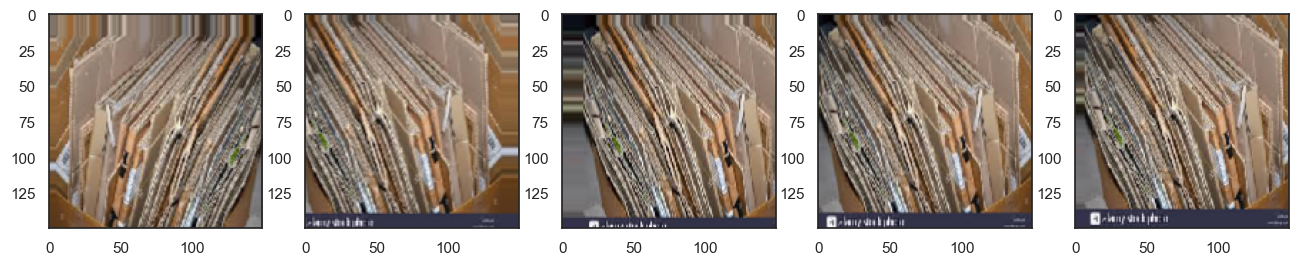

In [9]:
train_imgs, train_labels = getImagesData('train')
displayImage(train_imgs, train_labels, 1)

Below there are some helper functions used to create the CNN models based on VGG16 model.

In [ ]:
# creates a VGG16 model
def createVGGModel():
    vgg = vgg16.VGG16(include_top=False,
                        weights='imagenet',
                        input_shape=input_shape)
    
    return vgg

# creates a base model based on VGG16
def createBaseModel(isTrainable = False, trainableLayerStart = 0):
    vgg = createVGGModel()

    output = vgg.output
    output = tf.keras.layers.Flatten()(output)

    basemodel = Model(vgg.input, output)

    # set trainable layers based on trainableLayerStart
    if isTrainable == True:
        basemodel.trainable = True
        for layer in basemodel.layers[:trainableLayerStart]:
            layer.trainable = False
        for layer in basemodel.layers[trainableLayerStart:]:
            layer.trainable = True
    else:
        basemodel.trainable = False
        for layer in basemodel.layers: layer.trainable = False 

    return basemodel

# adds extra layers on the base model
def createModel(basemodel):
    input_shape = basemodel.output_shape[1]

    model = Sequential()
    model.add(basemodel)
    model.add(Dense(256, activation='relu', input_dim=input_shape))
    model.add(Dense(1, activation='sigmoid'))

    return model

def compile(model):
    model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
    
def fit(model):
    history = model.fit(train_generator, 
                              epochs=n_epochs,
                              validation_data=val_generator)  
    
    return history

# geenerates a classification report based on predictions for the data provided
def classificationReport(model, dataGenerator):
    predictions = model.predict(dataGenerator)

    predictions_class = num2class_lt(predictions)
    target_classes = num2class_lt(dataGenerator.classes)

    print('classification report')
    print(metrics.classification_report(target_classes, predictions_class))
    


# CNN


The first model and also the baseline will be a CNN created from scratch.  
Later we will compare the results of this CNN with the VGG16 models and see which is better.

In [11]:
model_cnn = Sequential()

model_cnn.add(Conv2D(32, (5, 5), padding='same', input_shape = (img_rows, img_cols, 3), activation = 'relu'))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
model_cnn.add(Flatten())

model_cnn.add(Dense(units = 256, activation = 'relu'))
model_cnn.add(Dense(units = 1, activation = 'sigmoid'))

In [12]:
model_cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      2432      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 75, 75, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 37, 37, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 87616)             0         
                                                                 
 dense (Dense)               (None, 256)               2

In [14]:
compile(model_cnn)

In [15]:
model_cnn_history = fit(model_cnn)

Epoch 1/6
182/182 [==============================] - 35s 164ms/step - loss: 0.6120 - accuracy: 0.7766 - val_loss: 0.4726 - val_accuracy: 0.7700
Epoch 2/6
182/182 [==============================] - 29s 157ms/step - loss: 0.4307 - accuracy: 0.8169 - val_loss: 0.4584 - val_accuracy: 0.7796
Epoch 3/6
182/182 [==============================] - 30s 162ms/step - loss: 0.4327 - accuracy: 0.8119 - val_loss: 0.4456 - val_accuracy: 0.7713
Epoch 4/6
182/182 [==============================] - 28s 155ms/step - loss: 0.4122 - accuracy: 0.8246 - val_loss: 0.4596 - val_accuracy: 0.7748
Epoch 5/6
182/182 [==============================] - 27s 150ms/step - loss: 0.3932 - accuracy: 0.8337 - val_loss: 0.4472 - val_accuracy: 0.7879
Epoch 6/6
182/182 [==============================] - 27s 150ms/step - loss: 0.3947 - accuracy: 0.8299 - val_loss: 0.4400 - val_accuracy: 0.7810


In [17]:
classificationReport(model_cnn, test_generator)

26/26 [==============================] - 1s 36ms/step
classification report
              precision    recall  f1-score   support

           O       0.81      0.92      0.86       465
           R       0.87      0.72      0.79       363

    accuracy                           0.83       828
   macro avg       0.84      0.82      0.82       828
weighted avg       0.83      0.83      0.83       828



# VGG-16


<img src="https://neurohive.io/wp-content/uploads/2018/11/vgg16-1-e1542731207177.png" />

It consists of 16 layers with trainable weights (hence the name "VGG16"), including convolutional layers, max-pooling layers, and fully connected layers.  
The network uses small convolutional filters (3x3) with a stride of 1 and applies them in layers, which allows for deeper feature extraction while keeping the architecture manageable.  
The max-pooling layers (2x2) help downsample the spatial dimensions of the image while retaining important features.

Input:
- It takes an image of size 224x224x3 as input, where 224x224 is the image resolution, and 3 represents the RGB color channels.

Output:
- For classification tasks, the output is a vector representing the predicted probabilities for each class. For example, when trained on ImageNet, it predicts among 1,000 classes.

In [18]:
basemodel_vgg = createBaseModel(isTrainable=False)
model_vgg = createModel(basemodel_vgg)

print(model_vgg.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model (Functional)          (None, 8192)              14714688  
                                                                 
 dense_2 (Dense)             (None, 256)               2097408   
                                                                 
 dense_3 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16,812,353
Trainable params: 2,097,665
Non-trainable params: 14,714,688
_________________________________________________________________
None


Unlike our baseline, this model has only 2,097,665 trainable params. That is because the VGG16 model layers are frozen and only the next layers are trainable.

In [19]:
compile(model_vgg)

In [20]:
history_vgg = fit(model_vgg)

Epoch 1/6
182/182 [==============================] - 38s 192ms/step - loss: 0.3838 - accuracy: 0.8386 - val_loss: 0.3551 - val_accuracy: 0.8540
Epoch 2/6
182/182 [==============================] - 31s 169ms/step - loss: 0.2761 - accuracy: 0.8892 - val_loss: 0.3918 - val_accuracy: 0.8430
Epoch 3/6
182/182 [==============================] - 30s 163ms/step - loss: 0.2420 - accuracy: 0.8969 - val_loss: 0.2971 - val_accuracy: 0.8898
Epoch 4/6
182/182 [==============================] - 29s 158ms/step - loss: 0.2239 - accuracy: 0.9090 - val_loss: 0.2818 - val_accuracy: 0.8898
Epoch 5/6
182/182 [==============================] - 29s 160ms/step - loss: 0.1932 - accuracy: 0.9200 - val_loss: 0.3412 - val_accuracy: 0.8595
Epoch 6/6
182/182 [==============================] - 29s 160ms/step - loss: 0.1820 - accuracy: 0.9274 - val_loss: 0.3171 - val_accuracy: 0.8678


In [21]:
classificationReport(model_vgg, test_generator)

26/26 [==============================] - 5s 204ms/step
classification report
              precision    recall  f1-score   support

           O       0.91      0.86      0.89       465
           R       0.83      0.90      0.86       363

    accuracy                           0.88       828
   macro avg       0.87      0.88      0.87       828
weighted avg       0.88      0.88      0.88       828



As we can see, the VGG16 model performs better than the baseline on every metrics, even though it has 10 times less trainable parameters.  
For example, the accuracy for the baseline is 83% while VGG16 has an accuracy of 88%.


# VGG-16 fine-tuned

In order to fine-tune the model, we will use the VGG-16 model but we will unfreeze last layers and keep the previous ones frozen. This ensures that the last layers of VGG16 are trainable; that is, weights get updated through backpropagation in each training iteration or epoch.

In [22]:
basemodel_vgg2 = createBaseModel(isTrainable=True, trainableLayerStart=17)
model_vgg2 = createModel(basemodel_vgg2)

print(model_vgg2.summary())

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model_1 (Functional)        (None, 8192)              14714688  
                                                                 
 dense_4 (Dense)             (None, 256)               2097408   
                                                                 
 dense_5 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16,812,353
Trainable params: 4,457,473
Non-trainable params: 12,354,880
_________________________________________________________________
None


The number of trainable params increased from the 1st VGG16 model we trained.  
That is because we unfroze the last layers from VGG16 model.

In [23]:
compile(model_vgg2)

In [24]:
history_vgg2 = fit(model_vgg2)

Epoch 1/6
182/182 [==============================] - 31s 164ms/step - loss: 0.4240 - accuracy: 0.8382 - val_loss: 0.3084 - val_accuracy: 0.8753
Epoch 2/6
182/182 [==============================] - 29s 158ms/step - loss: 0.2585 - accuracy: 0.9019 - val_loss: 0.3121 - val_accuracy: 0.8871
Epoch 3/6
182/182 [==============================] - 30s 162ms/step - loss: 0.2254 - accuracy: 0.9100 - val_loss: 0.3358 - val_accuracy: 0.8595
Epoch 4/6
182/182 [==============================] - 29s 161ms/step - loss: 0.1922 - accuracy: 0.9238 - val_loss: 0.3282 - val_accuracy: 0.8636
Epoch 5/6
182/182 [==============================] - 30s 166ms/step - loss: 0.1635 - accuracy: 0.9372 - val_loss: 0.3268 - val_accuracy: 0.8616
Epoch 6/6
182/182 [==============================] - 30s 165ms/step - loss: 0.1391 - accuracy: 0.9472 - val_loss: 0.4151 - val_accuracy: 0.8540


In [25]:
classificationReport(model_vgg2, test_generator)

26/26 [==============================] - 2s 86ms/step
classification report
              precision    recall  f1-score   support

           O       0.90      0.90      0.90       465
           R       0.87      0.87      0.87       363

    accuracy                           0.89       828
   macro avg       0.88      0.88      0.88       828
weighted avg       0.89      0.89      0.89       828



The accuracy increased to 89%, performing better than baseline and 1st VGG16 model.  
This means that unfrozing the last layers from VGG16 Helped our model perform better. 

# 4. Insights and key findings


The best performing model was the fine-tuned VGG16 model. In 2nd place came the default VGG16 model while the baseline CNN had the worst performance.  
This suggests that even though VGG16 model improved the performance that was not enough. Training the last layers of VGG16 on our dataset helped it perform better.

Also it is important to notice that the training times do not differ too much even though the baseline had the most trainable parameters with the worst performance.

# 5. Next Steps


Some of the next things to do that could improve the model performance:
- train on more epochs
- try to unfreeze more of the VGG16 layers
- try a different pre-trained model: ResNet, MobileNet, InceptionV3, etc.